# Skintellectual Shift: Understanding Consumer Trust in Cosmetic Brand Marketing

**Name:** Kanishka D  
**Register Number:** CB.SC.U4CSE23155  
**Domain:** Social Media Marketing

## Business Problem

A budget-constrained cosmetic startup needs to decide which marketing strategy should be emphasized first during its product launch: celebrity/influencer endorsement or ingredient transparency through visible ingredient disclosure and laboratory certifications.

Since the startup has a limited launch budget, both approaches cannot be given equal priority initially. This analysis studies consumer trust, purchase intention, demographic characteristics and social-media behaviour to understand the factors associated with purchase decisions.

## Objectives

1. Identify the key factors influencing consumer purchase intention, particularly celebrity endorsement trust and ingredient transparency trust.
2. Predict whether a consumer is likely or unlikely to purchase a new cosmetic brand using demographic, behavioural and trust-related variables.
3. Provide a data-driven recommendation for the first marketing strategy for a budget-constrained cosmetic startup.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [75]:
import pandas as pd
df_raw = pd.read_csv("data/final_dataset.csv")

print(f"Total Records: {df_raw.shape[0]} | Total Columns: {df_raw.shape[1]}")

Total Records: 10099 | Total Columns: 20


In [76]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10099 entries, 0 to 10098
Data columns (total 20 columns):
 #   Column                                                                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                                                                         --------------  ----- 
 0   What is your gender?                                                                                                                                                           10099 non-null  object
 1   What is your age group?                                                                                                                                                        10099 non-null  object
 2   How often do you purchase cosmetic or skincare products?                  

In [77]:
# renaming the cols
# and duplicates removed
rename_dict = {
    'What is your gender?': 'gender',
    'What is your age group?': 'age_group',
    'How often do you purchase cosmetic or skincare products?': 'purchase_freq',
    'Approximately how much do you spend on cosmetic or skincare products each month?': 'monthly_spend',
    'How often do you discover new cosmetic or skincare brands through social media?': 'discover_via_social',
    'How would you describe your daily skincare or cosmetic routine?': 'routine',
    'How much does a celebrity or influencer endorsement increase your trust in a cosmetic product?': 'celeb_trust_increase',
    'Would you be willing to pay more for a cosmetic product endorsed by a celebrity or influencer?': 'pay_more_for_celeb',
    "Do you feel there are too many celebrity or influencer cosmetic brands in today's market?": 'too_many_celeb_brands',
    'Have you ever purchased a cosmetic or skincare product because it was endorsed by a celebrity or influencer?': 'bought_due_to_endorsement',
    'If a new cosmetic brand only provides a basic ingredient list, how much extra would you be willing to pay?': 'extra_pay_basic_ingredients',
    'If a new cosmetic brand explains what each key ingredient does, how much extra would you be willing to pay?': 'extra_pay_explained_ingredients',
    'If a new cosmetic brand provides ingredient information along with independent laboratory testing, how much extra would you be willing to pay?': 'extra_pay_lab_tested',
    'Would you choose a new cosmetic brand over a famous brand if it provided scientific evidence supporting its product claims?': 'choose_new_over_famous',
    'If two cosmetic products have similar quality, which factor would most influence your purchase decision?': 'purchase_decision_factor',
    'How willing are you to try a newly launched cosmetic brand?': 'willing_to_try_new_brand',
    'Imagine a new cosmetic startup has a limited launch budget and can invest in only one of the following strategies. Which would make you more likely to purchase its products?': 'strategy_preference',
    'Based on the information provided by a new cosmetic brand, how much would you trust the brand overall?': 'overall_trust',
    "Overall, based on the startup's marketing approach and the information provided, how likely are you to purchase its product?": 'purchase_likely_raw',
    'data_source': 'data_source'
}

df = df_raw.rename(columns=rename_dict)
df = df.drop_duplicates().reset_index(drop=True)

print("cols successfully mapped and duplicate entries removed")

cols successfully mapped and duplicate entries removed


In [78]:
null_counts = df.isnull().sum()
print("Missing Value Summary:")
print(null_counts[null_counts > 0])

Missing Value Summary:
Series([], dtype: int64)


In [79]:
celeb_text_map = {"No": 0, "Maybe": 1, "Yes": 2}

transparency_text_map = {
    "0 INR (No extra)": 0,
    "Up to 5% more": 1,
    "5–10% more": 2,
    "5-10% more": 2,
    "More than 10% more": 3
}

for col in ["pay_more_for_celeb", "bought_due_to_endorsement"]:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].map(celeb_text_map)

for col in ["extra_pay_basic_ingredients", "extra_pay_explained_ingredients", "extra_pay_lab_tested"]:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].map(transparency_text_map)

df["celeb_trust_increase"] = pd.to_numeric(df["celeb_trust_increase"], errors="coerce")

# map binary target variable
target_map = {
    'Highly Unlikely': 0,
    'Unlikely': 0,
    'Likely': 1,
    'Highly Likely': 1
}

df['target'] = df['purchase_likely_raw'].map(target_map).astype(int)

print("encoding donee")

encoding donee


In [80]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

celeb_cols = [c for c in ['celeb_trust_increase', 'pay_more_for_celeb', 'bought_celeb_brand_past'] if c in df.columns]
transparency_cols = [c for c in ['extra_pay_basic', 'extra_pay_explained', 'extra_pay_lab_tested'] if c in df.columns]

df_celeb_scaled = pd.DataFrame(
    scaler.fit_transform(df[celeb_cols]), 
    columns=celeb_cols, 
    index=df.index
)
df['celebrity_trust_score'] = df_celeb_scaled.mean(axis=1)


df_transparency_scaled = pd.DataFrame(
    scaler.fit_transform(df[transparency_cols]), 
    columns=transparency_cols, 
    index=df.index
)
df['ingredient_transparency_score'] = df_transparency_scaled.mean(axis=1)

display(df[["celebrity_trust_score", "ingredient_transparency_score"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
celebrity_trust_score,6292.0,0.244795,0.231948,0.0,0.125,0.125000,0.375000,1.0
ingredient_transparency_score,6292.0,0.330896,0.325469,0.0,0.000,0.333333,0.666667,1.0


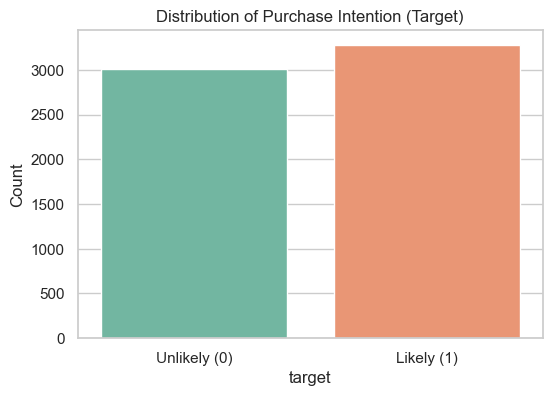

In [81]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title("Distribution of Purchase Intention (Target)")
plt.xticks([0, 1], ["Unlikely (0)", "Likely (1)"])
plt.ylabel("Count")
plt.show()

Purchase intention is classified as Likely (1) for consumers with higher trust and willingness to spend more on ingredient transparency, testing, scientific proof & Unlikely (0) for those with lower trust and spending willingness.

The chart shows that the Likely purchase intention group is slightly higher than the Unlikely group.
This indicates that more respondents are inclined to purchase the product.
However, the difference is small, so the dataset is relatively balanced between the two groups.

## Composite Score Distributions

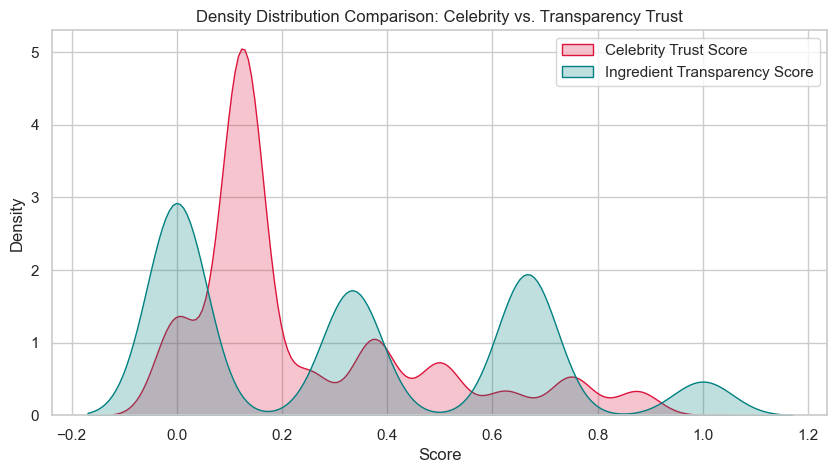

In [82]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df["celebrity_trust_score"], label="Celebrity Trust Score", fill=True, color="crimson")
sns.kdeplot(df["ingredient_transparency_score"], label="Ingredient Transparency Score", fill=True, color="teal")
plt.title("Density Distribution Comparison: Celebrity vs. Transparency Trust")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()

Consumers show heavily skewed, low trust toward celebrity endorsements, but spread out into significantly higher trust levels when provided with transparent ingredient details and lab testing

## Willingness to Pay across Transparency Levels

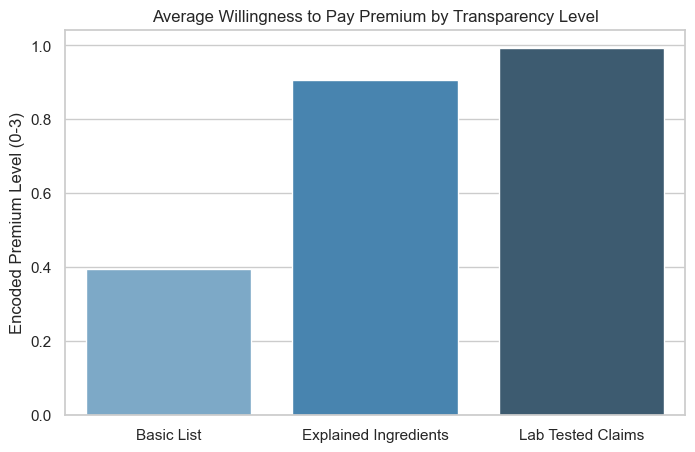

In [83]:
transparency_means = [
    df["extra_pay_basic_ingredients"].mean(),
    df["extra_pay_explained_ingredients"].mean(),
    df["extra_pay_lab_tested"].mean()
]
labels = ["Basic List", "Explained Ingredients", "Lab Tested Claims"]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=transparency_means, palette="Blues_d")
plt.title("Average Willingness to Pay Premium by Transparency Level")
plt.ylabel("Encoded Premium Level (0-3)")
plt.show()

The more detailed information and scientific lab proof a brand provides, the more extra money consumers are willing to pay for its products.

## Strategy Preference vs. Purchase Likelihood

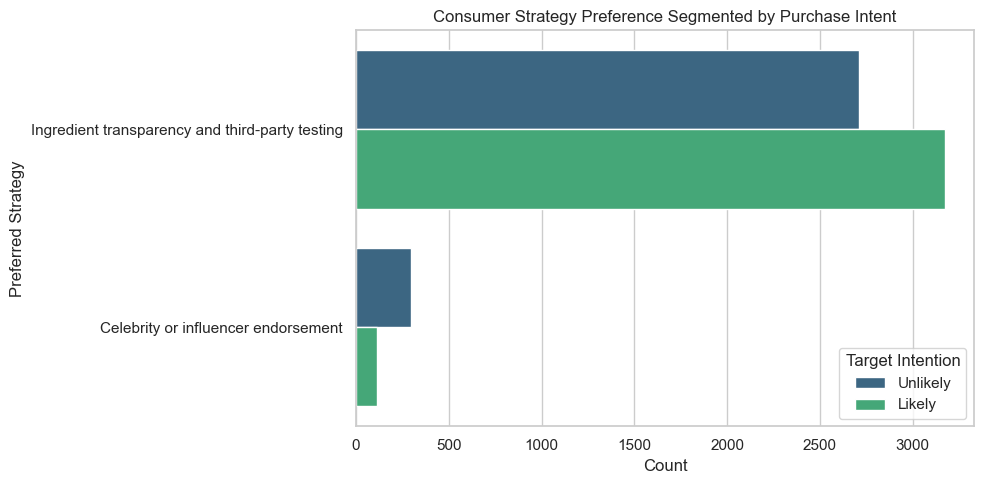

In [84]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="strategy_preference", hue="target", palette="viridis")
plt.title("Consumer Strategy Preference Segmented by Purchase Intent")
plt.xlabel("Count")
plt.ylabel("Preferred Strategy")
plt.legend(title="Target Intention", labels=["Unlikely", "Likely"])
plt.tight_layout()
plt.show()

Consumers place greater importance on ingredient transparency and lab testing than on celebrity endorsements.
Providing clear ingredient information and scientific validation is associated with stronger trust and purchase intention.

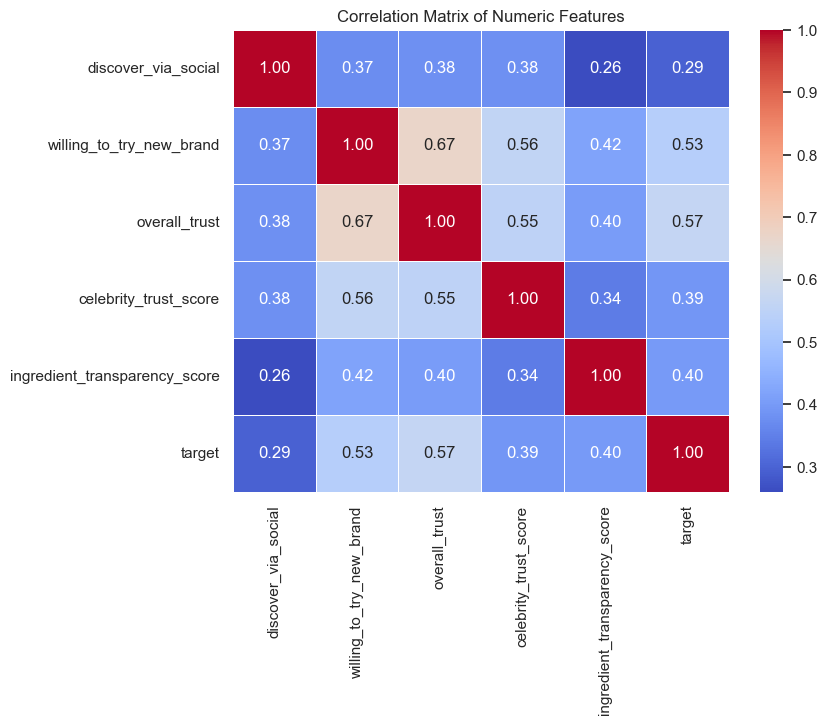

In [85]:
num_cols = [
    "discover_via_social", "willing_to_try_new_brand", "overall_trust",
    "celebrity_trust_score", "ingredient_transparency_score", "target"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Higher overall trust and willingness to try new brands show the strongest positive relationship with purchase intention.
Ingredient transparency also has a meaningful positive relationship, supporting the importance of building consumer trust.

In [86]:
num_features = [
    "discover_via_social", "willing_to_try_new_brand", "overall_trust",
    "celebrity_trust_score", "ingredient_transparency_score"
]

cat_features = [
    "gender", "age_group", "purchase_freq", "monthly_spend",
    "routine", "purchase_decision_factor", "strategy_preference"
]

df_encoded = pd.get_dummies(df[num_features + cat_features], drop_first=True)
X = df_encoded
y = df['target']

print(f"Feature Matrix Shape: {X.shape} | Target Array Shape: {y.shape}")

Feature Matrix Shape: (6292, 23) | Target Array Shape: (6292,)


In [87]:
#  train-test split & standard scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model 1 - Logistic Regression

In [88]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]


## Model 2 - Decision Tree Classifier

In [89]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

## Model 3 - Random Forest Classifier

In [90]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [91]:
models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest": (y_pred_rf, y_prob_rf)
}

results = []
for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

eval_df = pd.DataFrame(results)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.781573,0.798438,0.777778,0.787972,0.878461
1,Decision Tree,0.782367,0.795981,0.783866,0.789877,0.871603
2,Random Forest,0.777601,0.790447,0.780822,0.785605,0.878380


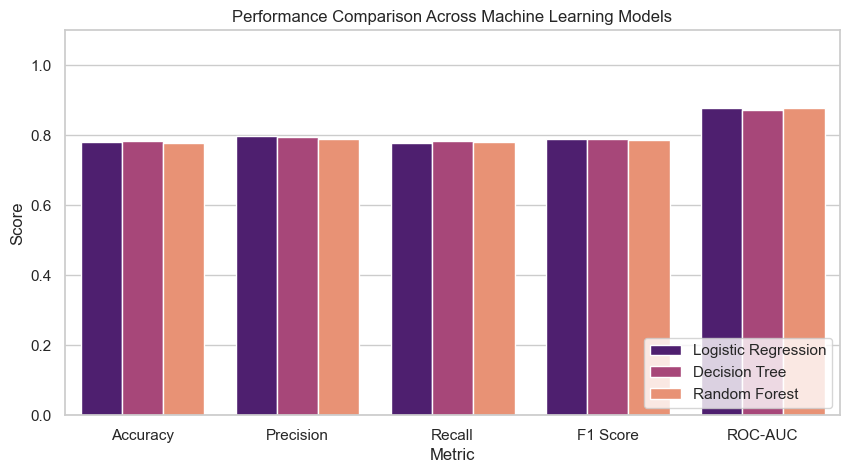

In [92]:
eval_melted = eval_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=eval_melted, x="Metric", y="Score", hue="Model", palette="magma")
plt.title("Performance Comparison Across Machine Learning Models")
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.show()

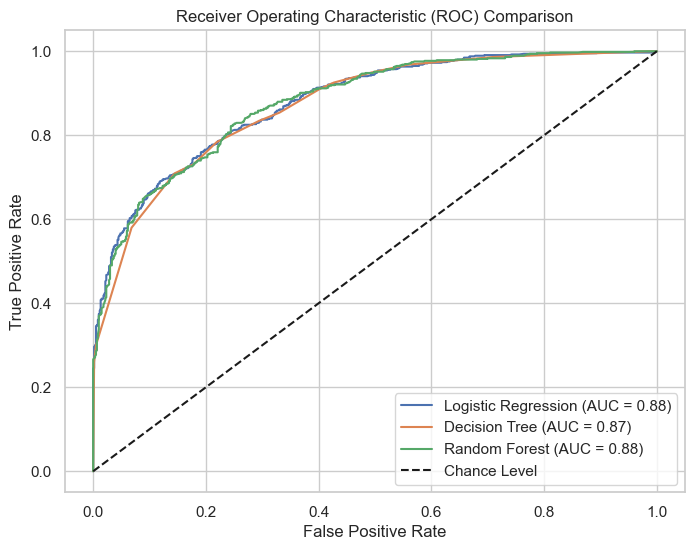

In [93]:
plt.figure(figsize=(8, 6))

for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend()
plt.show()

Logistic Regression and Random Forest achieved the highest ROC-AUC of 0.878, while Logistic Regression is easier to interpret.  
The models achieved around 78% accuracy, showing good prediction of purchase intention on unseen data.  
Overall trust (0.57) and willingness to try new brands (0.53) are the strongest statistical drivers of purchase intention.

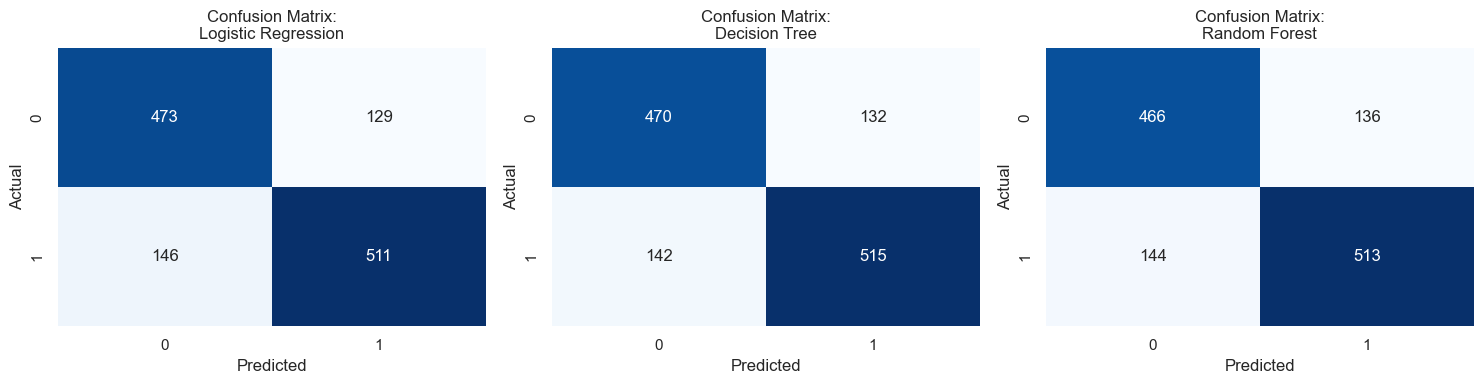

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix:\n{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

All three models show strong, balanced predictions by correctly identifying roughly 470 non-buyers and 513 actual buyers with minimal classification errors. Errors are evenly split between false positives and false negatives, proving that none of the algorithms suffer from predictive bias. Logistic Regression performs best overall by minimizing false positives to 129, making it the safest model for guiding startup marketing decisions.

Feature Importance Comparison

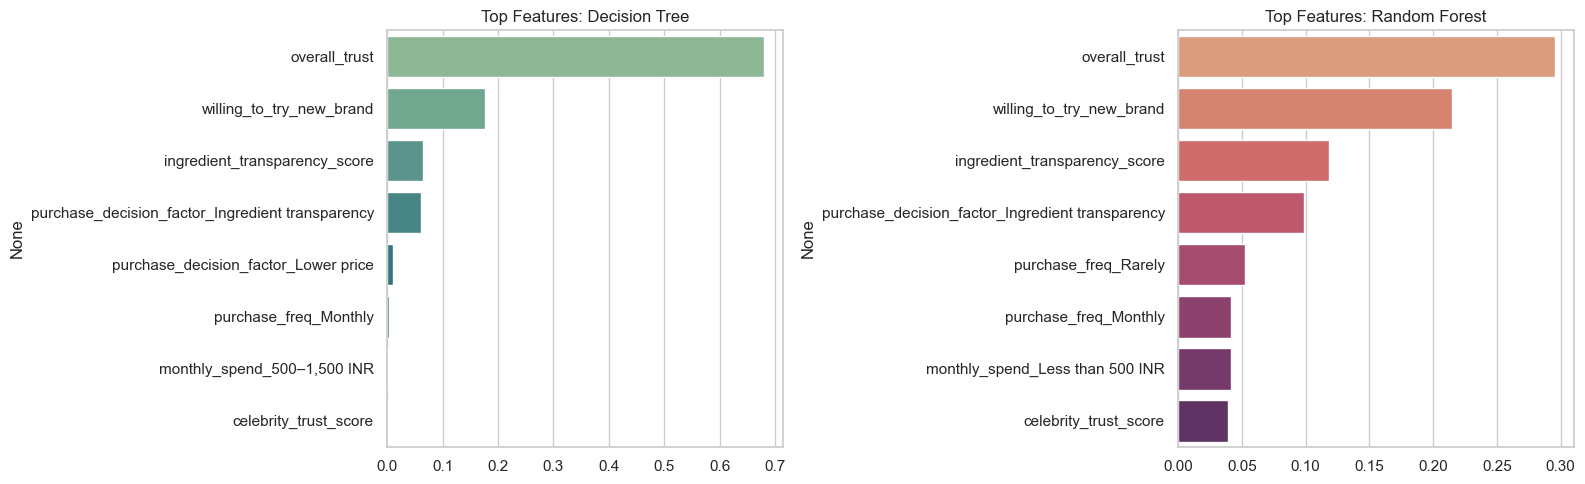

In [95]:
dt_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=dt_imp.values, y=dt_imp.index, ax=axes[0], palette="crest")
axes[0].set_title("Top Features: Decision Tree")

sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=axes[1], palette="flare")
axes[1].set_title("Top Features: Random Forest")

plt.tight_layout()
plt.show()

Logistic Regression Coefficient Analysis

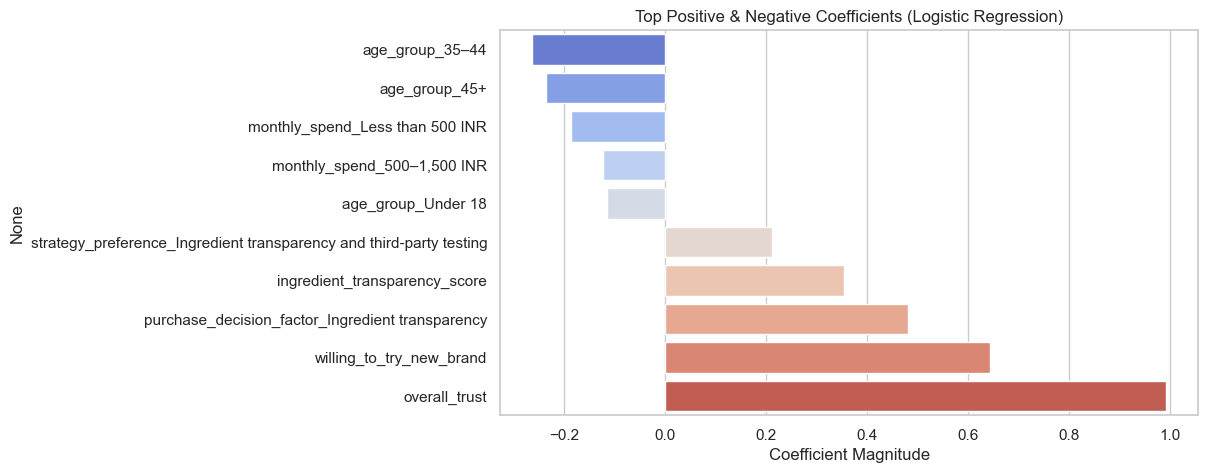

In [96]:
lr_coef = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
top_bottom_coef = pd.concat([lr_coef.head(5), lr_coef.tail(5)])

plt.figure(figsize=(9, 5))
sns.barplot(x=top_bottom_coef.values, y=top_bottom_coef.index, palette="coolwarm")
plt.title("Top Positive & Negative Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Magnitude")
plt.show()

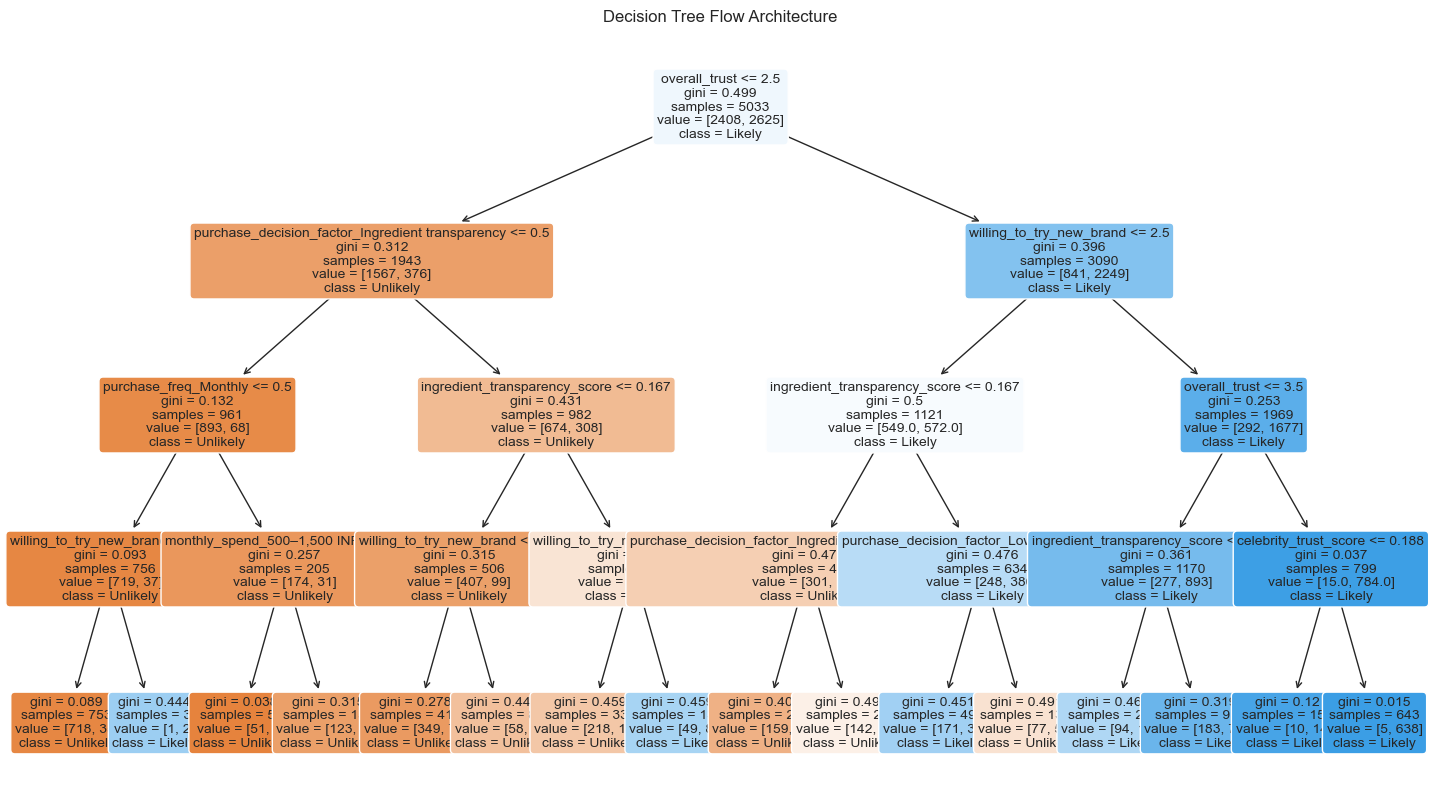

In [97]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Unlikely", "Likely"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Flow Architecture")
plt.show()

The top root split shows that overall trust is the primary decision factor, splitting 5,033 samples based on trust threshold. Consumers with low trust are immediately funneled left to evaluate ingredient transparency, where low transparency scores lead directly to the Unlikely purchase class. Conversely, high trust branches right toward willing to try new brand and transparency metrics, consistently terminating in high-confidence Likely purchase classifications.

## 1. Strategic Capital Allocation

**Prioritize Transparency Over Fame:** Direct marketing budgets toward third-party lab testing and clear ingredient information rather than expensive celebrity endorsements.

**Use Influencers Later:** Use celebrity and influencer partnerships as a secondary strategy after the brand has built trust and demonstrated product quality.

## 2. Product Marketing & Messaging

**Provide Scientific Proof:** Go beyond basic ingredient lists by explaining active ingredients and showing verified lab-test results.

**Support Premium Pricing:** Clear information and verified claims can increase consumers’ willingness to pay more.

## 3. Customer Acquisition & Validation

**Target Early Adopters:** Focus initial campaigns on consumers who are **willing to try new brands**, as they show higher trust and purchase intention.